# Circular Trajectory Agility Analysis

This notebook analyzes the agility demonstration flight tests conducted at different speeds (3, 5, 6.5, and 8 m/s) flying circular trajectories.

**Data location:** `../logs/Circle/` with subfolders for each speed (3mps, 5mps, 6mps5, 8mps)

**Analysis objectives:**
1. Calculate tracking errors (RMS and max deviation from reference circle)
2. Calculate bank angles and centripetal accelerations
3. Generate comparative plots for thesis
4. Export data to CSV files for LaTeX pgfplots

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

# Set up matplotlib for better-looking plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [45]:
# Define data paths
base_path = Path('../logs/Circle')
speeds = [3, 5, 6.5, 8]  # m/s
speed_folders = {
    3: '3mps',
    5: '5mps',
    6.5: '6mps5',  # Note: folder is named 6mps5, not 6.5mps
    8: '8mps'
}

# Function to load data by topic from CSV
def load_topic_data(filepath, topic_name):
    """Load data for a specific topic from a CSV file."""
    df = pd.read_csv(filepath)
    # Filter by topic
    topic_data = df[df['topic'] == topic_name].copy()
    # Reset index and return time and value columns
    topic_data = topic_data[['elapsed time', 'value']].reset_index(drop=True)
    topic_data.columns = ['time', 'value']
    return topic_data

# Define topic names for each data type
topics = {
    'pos_x_measured': '/mocap/xwing/pose.pose.position.x',
    'pos_x_reference': '/xwing/agiros_pilot/telemetry.reference.pose.position.x',
    'pos_y_measured': '/mocap/xwing/pose.pose.position.y',
    'pos_y_reference': '/xwing/agiros_pilot/telemetry.reference.pose.position.y',
    'pos_z_measured': '/mocap/xwing/pose.pose.position.z',
    'pos_z_reference': '/xwing/agiros_pilot/telemetry.reference.pose.position.z',
    'roll_measured': '/studio/euler_deg.meas_roll_deg',
    'roll_reference': '/studio/euler_deg.ref_roll_deg',
    'pitch_measured': '/studio/euler_deg.meas_pitch_deg',
    'pitch_reference': '/studio/euler_deg.ref_pitch_deg',
    'yaw_measured': '/studio/euler_deg.meas_yaw_deg',
    'yaw_reference': '/studio/euler_deg.ref_yaw_deg',
    'roll_error': '/studio/euler_deg.err_roll_deg',
    'pitch_error': '/studio/euler_deg.err_pitch_deg',
    'yaw_error': '/studio/euler_deg.err_yaw_deg'
}

# Load data for each speed
data = {}

for speed in speeds:
    folder = base_path / speed_folders[speed]
    
    data[speed] = {}
    
    # Check if folder exists
    if not folder.exists():
        print(f"Error: Folder not found for speed {speed} m/s: {folder}")
        continue
    
    # Load position data (x, y, z)
    try:
        data[speed]['x_measured'] = load_topic_data(folder / 'pos_x.csv', topics['pos_x_measured'])
        data[speed]['x_reference'] = load_topic_data(folder / 'pos_x.csv', topics['pos_x_reference'])
        data[speed]['y_measured'] = load_topic_data(folder / 'pos_y.csv', topics['pos_y_measured'])
        data[speed]['y_reference'] = load_topic_data(folder / 'pos_y.csv', topics['pos_y_reference'])
        data[speed]['z_measured'] = load_topic_data(folder / 'pos_z.csv', topics['pos_z_measured'])
        data[speed]['z_reference'] = load_topic_data(folder / 'pos_z.csv', topics['pos_z_reference'])
        
        print(f"Speed {speed} m/s - Position data loaded:")
        print(f"  X: {len(data[speed]['x_measured'])} measured, {len(data[speed]['x_reference'])} reference points")
        
    except Exception as e:
        print(f"Warning: Could not load position data for {speed} m/s: {e}")
    
    # Load orientation data (roll, pitch, yaw)
    try:
        data[speed]['roll_measured'] = load_topic_data(folder / 'roll.csv', topics['roll_measured'])
        data[speed]['roll_reference'] = load_topic_data(folder / 'roll.csv', topics['roll_reference'])
        data[speed]['pitch_measured'] = load_topic_data(folder / 'pitch.csv', topics['pitch_measured'])
        data[speed]['pitch_reference'] = load_topic_data(folder / 'pitch.csv', topics['pitch_reference'])
        data[speed]['yaw_measured'] = load_topic_data(folder / 'yaw.csv', topics['yaw_measured'])
        data[speed]['yaw_reference'] = load_topic_data(folder / 'yaw.csv', topics['yaw_reference'])
        
        print(f"  Orientation: {len(data[speed]['roll_measured'])} data points")
        
    except Exception as e:
        print(f"Warning: Could not load orientation data for {speed} m/s: {e}")
    
    # Load orientation errors
    try:
        data[speed]['roll_error'] = load_topic_data(folder / 'orientation_error.csv', topics['roll_error'])
        data[speed]['pitch_error'] = load_topic_data(folder / 'orientation_error.csv', topics['pitch_error'])
        data[speed]['yaw_error'] = load_topic_data(folder / 'orientation_error.csv', topics['yaw_error'])
        
        print(f"  Errors: {len(data[speed]['roll_error'])} error points")
        
    except Exception as e:
        print(f"Warning: Could not load error data for {speed} m/s: {e}")
    
    print()

print("Data loading complete!")

Speed 3 m/s - Position data loaded:
  X: 1219 measured, 3661 reference points
  Orientation: 4880 data points
  Errors: 4880 error points

Speed 5 m/s - Position data loaded:
  X: 600 measured, 1804 reference points
  Orientation: 2404 data points
  Errors: 2404 error points

Speed 6.5 m/s - Position data loaded:
  X: 604 measured, 1813 reference points
  Orientation: 1417 data points
  Errors: 2417 error points

Speed 8 m/s - Position data loaded:
  X: 702 measured, 2109 reference points
  Orientation: 2811 data points
  Errors: 2811 error points

Data loading complete!


In [46]:
# Load motor speed data for all speeds
motor_speeds = {}

for speed in speeds:
    folder = base_path / speed_folders[speed]
    
    try:
        motor_data = load_topic_data(folder / 'average_motor_speed.csv', '/studio/rotor_avg_rpm.mean_rpm')
        
        if len(motor_data) > 0:
            motor_speeds[speed] = {
                'time': motor_data['time'].values,
                'rpm': motor_data['value'].values,
                'mean_rpm': np.mean(motor_data['value'].values),
                'std_rpm': np.std(motor_data['value'].values),
                'max_rpm': np.max(motor_data['value'].values),
                'min_rpm': np.min(motor_data['value'].values)
            }
            
            print(f"Speed {speed} m/s:")
            print(f"  Mean motor RPM: {motor_speeds[speed]['mean_rpm']:.1f}")
            print(f"  Std motor RPM: {motor_speeds[speed]['std_rpm']:.1f}")
            print(f"  Max motor RPM: {motor_speeds[speed]['max_rpm']:.1f}")
            print()
    except Exception as e:
        print(f"Warning: Could not load motor speed data for {speed} m/s: {e}")

print("Motor speed data loaded!")

Speed 3 m/s:
  Mean motor RPM: 1288.8
  Std motor RPM: 10.9
  Max motor RPM: 1318.7

Speed 5 m/s:
  Mean motor RPM: 1464.5
  Std motor RPM: 122.2
  Max motor RPM: 1587.9

Speed 6.5 m/s:
  Mean motor RPM: 1402.5
  Std motor RPM: 231.2
  Max motor RPM: 1856.9

Speed 8 m/s:
  Mean motor RPM: 1395.8
  Std motor RPM: 259.3
  Max motor RPM: 1961.2

Motor speed data loaded!


In [47]:
# Calculate circle parameters
# Assuming 4.6m radius circle (adjust if different)
reference_radius = 4.6  # m
g = 9.81  # m/s^2

# Calculate ideal centripetal acceleration and bank angle for each speed
circle_params = {}

for speed in speeds:
    v = speed
    a_c = v**2 / reference_radius  # centripetal acceleration
    phi_ideal = np.arctan(a_c / g) * 180 / np.pi  # ideal bank angle in degrees
    
    circle_params[speed] = {
        'speed': v,
        'radius': reference_radius,
        'centripetal_accel': a_c,
        'ideal_bank_angle_deg': phi_ideal
    }
    
    print(f"Speed {speed} m/s:")
    print(f"  Centripetal acceleration: {a_c:.2f} m/s²")
    print(f"  Ideal bank angle: {phi_ideal:.1f}°")
    print()

Speed 3 m/s:
  Centripetal acceleration: 1.96 m/s²
  Ideal bank angle: 11.3°

Speed 5 m/s:
  Centripetal acceleration: 5.43 m/s²
  Ideal bank angle: 29.0°

Speed 6.5 m/s:
  Centripetal acceleration: 9.18 m/s²
  Ideal bank angle: 43.1°

Speed 8 m/s:
  Centripetal acceleration: 13.91 m/s²
  Ideal bank angle: 54.8°



In [48]:
# Diagnostic: Check what data was loaded for each speed
print("Data availability check:")
print("=" * 60)
for speed in speeds:
    print(f"\nSpeed {speed} m/s:")
    print(f"  Keys available: {list(data[speed].keys())}")
    
    # Check position data
    pos_keys = ['x_measured', 'y_measured', 'z_measured', 'x_reference', 'y_reference', 'z_reference']
    missing_pos = [k for k in pos_keys if k not in data[speed]]
    if missing_pos:
        print(f"  ⚠️  Missing position data: {missing_pos}")
    else:
        print(f"  ✓ All position data loaded")
    
    # Check orientation data
    orient_keys = ['roll_measured', 'pitch_measured', 'yaw_measured', 
                   'roll_reference', 'pitch_reference', 'yaw_reference']
    missing_orient = [k for k in orient_keys if k not in data[speed]]
    if missing_orient:
        print(f"  ⚠️  Missing orientation data: {missing_orient}")
    else:
        print(f"  ✓ All orientation data loaded")

print("\n" + "=" * 60)

Data availability check:

Speed 3 m/s:
  Keys available: ['x_measured', 'x_reference', 'y_measured', 'y_reference', 'z_measured', 'z_reference', 'roll_measured', 'roll_reference', 'pitch_measured', 'pitch_reference', 'yaw_measured', 'yaw_reference', 'roll_error', 'pitch_error', 'yaw_error']
  ✓ All position data loaded
  ✓ All orientation data loaded

Speed 5 m/s:
  Keys available: ['x_measured', 'x_reference', 'y_measured', 'y_reference', 'z_measured', 'z_reference', 'roll_measured', 'roll_reference', 'pitch_measured', 'pitch_reference', 'yaw_measured', 'yaw_reference', 'roll_error', 'pitch_error', 'yaw_error']
  ✓ All position data loaded
  ✓ All orientation data loaded

Speed 6.5 m/s:
  Keys available: ['x_measured', 'x_reference', 'y_measured', 'y_reference', 'z_measured', 'z_reference', 'roll_measured', 'roll_reference', 'pitch_measured', 'pitch_reference', 'yaw_measured', 'yaw_reference', 'roll_error', 'pitch_error', 'yaw_error']
  ✓ All position data loaded
  ✓ All orientation d

In [49]:
# Calculate tracking metrics for each speed
tracking_metrics = {}

for speed in speeds:
    # Check if data exists for this speed
    if 'x_measured' not in data[speed] or 'y_measured' not in data[speed]:
        print(f"Warning: Skipping speed {speed} m/s - missing position data")
        print(f"  Available keys: {list(data[speed].keys())}")
        continue
    
    # Get measured and reference positions
    x_meas = data[speed]['x_measured']['value'].values
    y_meas = data[speed]['y_measured']['value'].values
    z_meas = data[speed]['z_measured']['value'].values
    x_ref = data[speed]['x_reference']['value'].values
    y_ref = data[speed]['y_reference']['value'].values
    z_ref = data[speed]['z_reference']['value'].values
    
    # Interpolate reference to match measured timestamps if needed
    time_meas = data[speed]['x_measured']['time'].values
    time_ref = data[speed]['x_reference']['time'].values
    
    if len(time_meas) != len(time_ref):
        # Interpolate reference to measured time points
        x_ref_interp = np.interp(time_meas, time_ref, x_ref)
        y_ref_interp = np.interp(time_meas, time_ref, y_ref)
        z_ref_interp = np.interp(time_meas, time_ref, z_ref)
    else:
        x_ref_interp = x_ref
        y_ref_interp = y_ref
        z_ref_interp = z_ref
    
    # Calculate position errors
    x_error = x_meas - x_ref_interp
    y_error = y_meas - y_ref_interp
    z_error = z_meas - z_ref_interp
    
    # Calculate horizontal tracking error (in XY plane only)
    horizontal_error = np.sqrt(x_error**2 + y_error**2)
    
    # Calculate 3D tracking error (including Z)
    error_3d = np.sqrt(x_error**2 + y_error**2 + z_error**2)
    
    rms_error_xy = np.sqrt(np.mean(horizontal_error**2))
    rms_error_3d = np.sqrt(np.mean(error_3d**2))
    max_error = np.max(horizontal_error)
    max_error_3d = np.max(error_3d)
    mean_error = np.mean(horizontal_error)
    
    tracking_metrics[speed] = {
        'rms_error': rms_error_3d,  # 3D RMS error
        'rms_error_xy': rms_error_xy,  # XY-only RMS error
        'max_error': max_error,
        'max_error_3d': max_error_3d,
        'mean_error': mean_error,
        'horizontal_error': horizontal_error,
        'error_3d': error_3d,
        'x_error': x_error,
        'y_error': y_error,
        'z_error': z_error,
        'time': time_meas
    }
    
    print(f"Speed {speed} m/s:")
    print(f"  RMS tracking error (3D): {rms_error_3d:.3f} m")
    print(f"  RMS tracking error (XY): {rms_error_xy:.3f} m")
    print(f"  Max tracking error (XY): {max_error:.3f} m")
    print(f"  Max tracking error (3D): {max_error_3d:.3f} m")
    print(f"  Mean tracking error: {mean_error:.3f} m")
    print()


Speed 3 m/s:
  RMS tracking error (3D): 0.064 m
  RMS tracking error (XY): 0.032 m
  Max tracking error (XY): 0.056 m
  Max tracking error (3D): 0.088 m
  Mean tracking error: 0.029 m

Speed 5 m/s:
  RMS tracking error (3D): 0.238 m
  RMS tracking error (XY): 0.109 m
  Max tracking error (XY): 0.172 m
  Max tracking error (3D): 0.310 m
  Mean tracking error: 0.102 m

Speed 6.5 m/s:
  RMS tracking error (3D): 0.155 m
  RMS tracking error (XY): 0.137 m
  Max tracking error (XY): 0.348 m
  Max tracking error (3D): 0.386 m
  Mean tracking error: 0.098 m

Speed 8 m/s:
  RMS tracking error (3D): 0.184 m
  RMS tracking error (XY): 0.162 m
  Max tracking error (XY): 0.454 m
  Max tracking error (3D): 0.538 m
  Mean tracking error: 0.098 m



In [50]:
# Calculate bank angles from orientation data
bank_angles = {}

for speed in speeds:
    # Check if data exists for this speed
    if 'roll_measured' not in data[speed]:
        print(f"Warning: Skipping speed {speed} m/s - missing orientation data")
        print(f"  Available keys: {list(data[speed].keys())}")
        continue
    
    # Get roll data (already in degrees based on topic name)
    roll_data = data[speed]['roll_measured']['value'].values
    roll_ref = data[speed]['roll_reference']['value'].values
    time = data[speed]['roll_measured']['time'].values
    
    # Bank angle is the roll angle during circular flight
    mean_bank = np.mean(np.abs(roll_data))
    max_bank = np.max(np.abs(roll_data))
    std_bank = np.std(roll_data)
    mean_ref_bank = np.mean(np.abs(roll_ref))
    
    bank_angles[speed] = {
        'mean_abs_bank': mean_bank,
        'max_abs_bank': max_bank,
        'std_bank': std_bank,
        'mean_ref_bank': mean_ref_bank,
        'roll_data': roll_data,
        'roll_ref': roll_ref,
        'time': time,
        'ideal_bank': circle_params[speed]['ideal_bank_angle_deg']
    }
    
    print(f"Speed {speed} m/s:")
    print(f"  Mean absolute bank angle (measured): {mean_bank:.1f}°")
    print(f"  Mean absolute bank angle (reference): {mean_ref_bank:.1f}°")
    print(f"  Max absolute bank angle: {max_bank:.1f}°")
    print(f"  Ideal bank angle (theoretical): {circle_params[speed]['ideal_bank_angle_deg']:.1f}°")
    print(f"  Bank angle deviation: {mean_bank - circle_params[speed]['ideal_bank_angle_deg']:.1f}°")
    print()

Speed 3 m/s:
  Mean absolute bank angle (measured): 25.5°
  Mean absolute bank angle (reference): 24.8°
  Max absolute bank angle: 29.8°
  Ideal bank angle (theoretical): 11.3°
  Bank angle deviation: 14.3°

Speed 5 m/s:
  Mean absolute bank angle (measured): 40.6°
  Mean absolute bank angle (reference): 39.6°
  Max absolute bank angle: 57.3°
  Ideal bank angle (theoretical): 29.0°
  Bank angle deviation: 11.6°

Speed 6.5 m/s:
  Mean absolute bank angle (measured): 34.2°
  Mean absolute bank angle (reference): 35.1°
  Max absolute bank angle: 70.0°
  Ideal bank angle (theoretical): 43.1°
  Bank angle deviation: -8.9°

Speed 8 m/s:
  Mean absolute bank angle (measured): 17.0°
  Mean absolute bank angle (reference): 17.5°
  Max absolute bank angle: 76.8°
  Ideal bank angle (theoretical): 54.8°
  Bank angle deviation: -37.8°



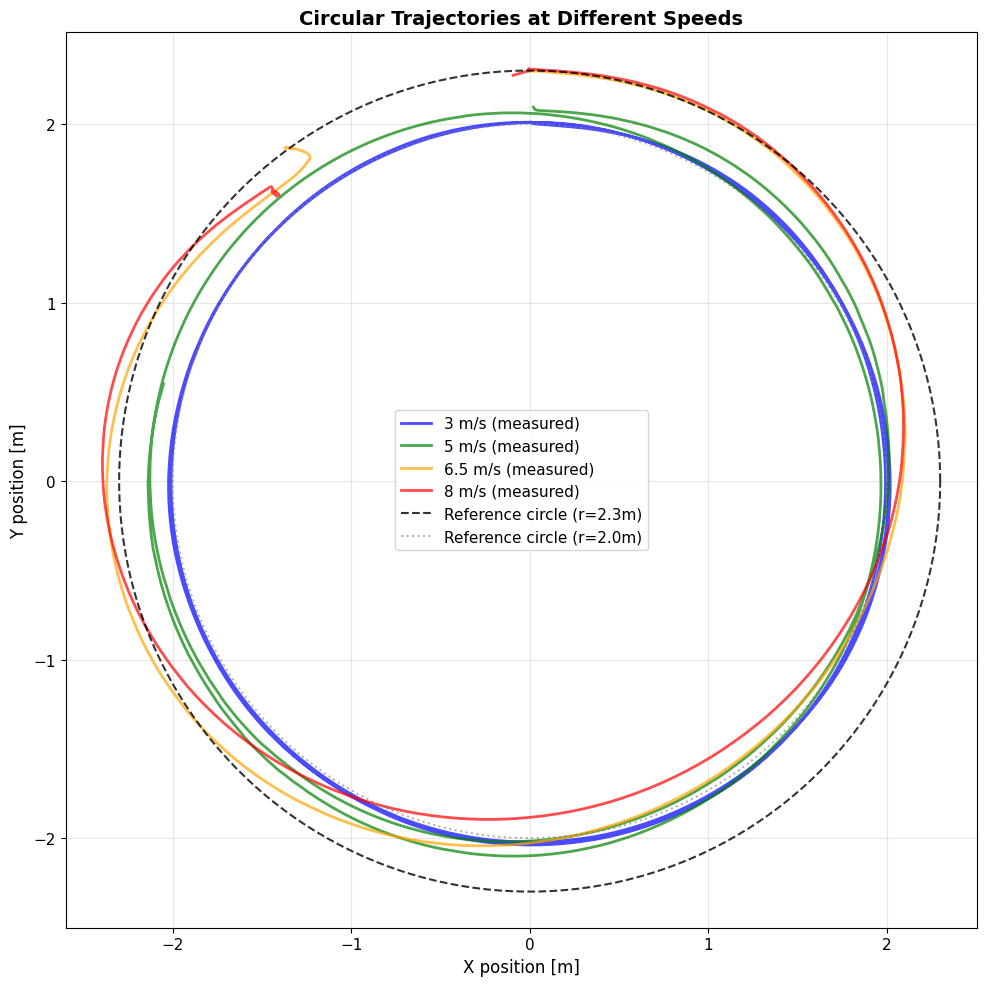

2D trajectory plot generated


In [51]:
# Plot 1: 2D trajectories for all speeds
fig, ax = plt.subplots(figsize=(10, 10))

colors = {3: 'blue', 5: 'green', 6.5: 'orange', 8: 'red'}
y_offsets = {3: -0.3, 5: -0.3, 6.5: -0.3, 8: -0.3}

for speed in speeds:
    if 'x_measured' not in data[speed] or 'y_measured' not in data[speed]:
        print(f"Warning: Skipping speed {speed} m/s - missing position data for plot")
        continue
        
    x_meas = data[speed]['x_measured']['value'].values
    y_meas = data[speed]['y_measured']['value'].values + y_offsets[speed]
    
    ax.plot(x_meas, y_meas, color=colors[speed], 
            label=f'{speed} m/s (measured)', linewidth=2, alpha=0.7)

# Plot perfect reference circle with radius 2.3 m centered at (0, 0)
theta = np.linspace(0, 2*np.pi, 200)
x_ref = 2.3 * np.cos(theta)
y_ref = 2.3 * np.sin(theta)
ax.plot(x_ref, y_ref, 'k--', linewidth=1.5, label='Reference circle (r=2.3m)', alpha=0.8)

# Plot second reference circle with radius 2 m centered at (0, 0)
x_ref2 = 2.0 * np.cos(theta)
y_ref2 = 2.0 * np.sin(theta)
ax.plot(x_ref2, y_ref2, 'gray', linestyle=':', linewidth=1.5, label='Reference circle (r=2.0m)', alpha=0.6)

ax.set_xlabel('X position [m]', fontsize=12)
ax.set_ylabel('Y position [m]', fontsize=12)
ax.set_title('Circular Trajectories at Different Speeds', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axis('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("2D trajectory plot generated")

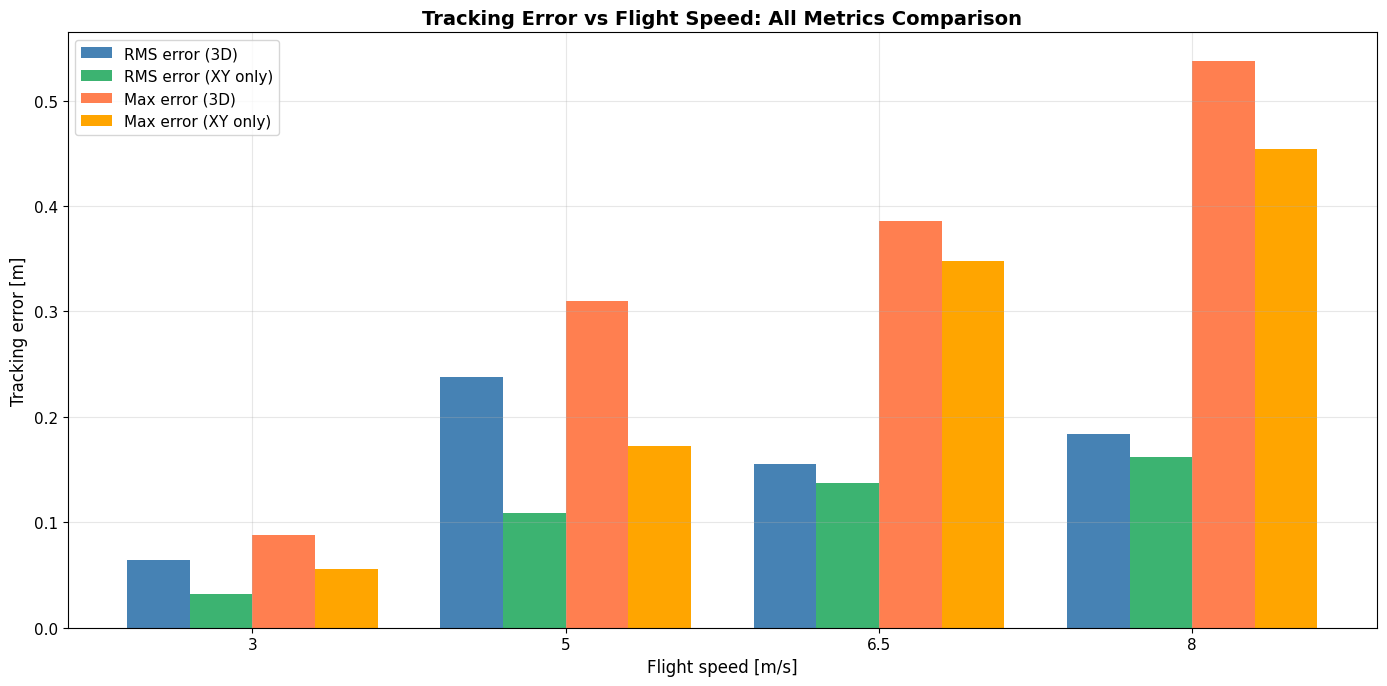

Tracking error plot generated

Detailed Error Comparison:
Speed      RMS 3D       RMS XY       Max 3D       Max XY      
[m/s]      [m]          [m]          [m]          [m]         
----------------------------------------------------------------------
3.0        0.0641       0.0324       0.0880       0.0556      
5.0        0.2380       0.1088       0.3103       0.1721      
6.5        0.1552       0.1370       0.3856       0.3477      
8.0        0.1837       0.1622       0.5379       0.4539      

Z-component contribution (difference between 3D and XY):
----------------------------------------------------------------------
3 m/s: RMS diff = 0.0317 m (49.5%), Max diff = 0.0324 m (36.8%)
5 m/s: RMS diff = 0.1293 m (54.3%), Max diff = 0.1382 m (44.5%)
6.5 m/s: RMS diff = 0.0182 m (11.7%), Max diff = 0.0379 m (9.8%)
8 m/s: RMS diff = 0.0215 m (11.7%), Max diff = 0.0840 m (15.6%)


In [52]:
# Plot 2: Tracking error vs speed - showing all metrics in one plot
fig, ax = plt.subplots(figsize=(14, 7))

speeds_list = list(tracking_metrics.keys())
rms_errors_3d = [tracking_metrics[s]['rms_error'] for s in speeds_list]
rms_errors_xy = [tracking_metrics[s]['rms_error_xy'] for s in speeds_list]
max_errors_3d = [tracking_metrics[s]['max_error_3d'] for s in speeds_list]
max_errors_xy = [tracking_metrics[s]['max_error'] for s in speeds_list]

x_pos = np.arange(len(speeds_list))
width = 0.2

# All four bars
ax.bar(x_pos - 1.5*width, rms_errors_3d, width, label='RMS error (3D)', color='steelblue')
ax.bar(x_pos - 0.5*width, rms_errors_xy, width, label='RMS error (XY only)', color='mediumseagreen')
ax.bar(x_pos + 0.5*width, max_errors_3d, width, label='Max error (3D)', color='coral')
ax.bar(x_pos + 1.5*width, max_errors_xy, width, label='Max error (XY only)', color='orange')

ax.set_xlabel('Flight speed [m/s]', fontsize=12)
ax.set_ylabel('Tracking error [m]', fontsize=12)
ax.set_title('Tracking Error vs Flight Speed: All Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{s}' for s in speeds_list])
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Tracking error plot generated\n")
print("="*70)
print("Detailed Error Comparison:")
print("="*70)
print(f"{'Speed':<10} {'RMS 3D':<12} {'RMS XY':<12} {'Max 3D':<12} {'Max XY':<12}")
print(f"{'[m/s]':<10} {'[m]':<12} {'[m]':<12} {'[m]':<12} {'[m]':<12}")
print("-"*70)
for speed, rms_3d, rms_xy, max_3d, max_xy in zip(speeds_list, rms_errors_3d, rms_errors_xy, max_errors_3d, max_errors_xy):
    print(f"{speed:<10.1f} {rms_3d:<12.4f} {rms_xy:<12.4f} {max_3d:<12.4f} {max_xy:<12.4f}")
print("="*70)
print("\nZ-component contribution (difference between 3D and XY):")
print("-"*70)
for speed, rms_3d, rms_xy, max_3d, max_xy in zip(speeds_list, rms_errors_3d, rms_errors_xy, max_errors_3d, max_errors_xy):
    rms_diff = rms_3d - rms_xy
    max_diff = max_3d - max_xy
    print(f"{speed} m/s: RMS diff = {rms_diff:.4f} m ({100*rms_diff/rms_3d:.1f}%), Max diff = {max_diff:.4f} m ({100*max_diff/max_3d:.1f}%)")


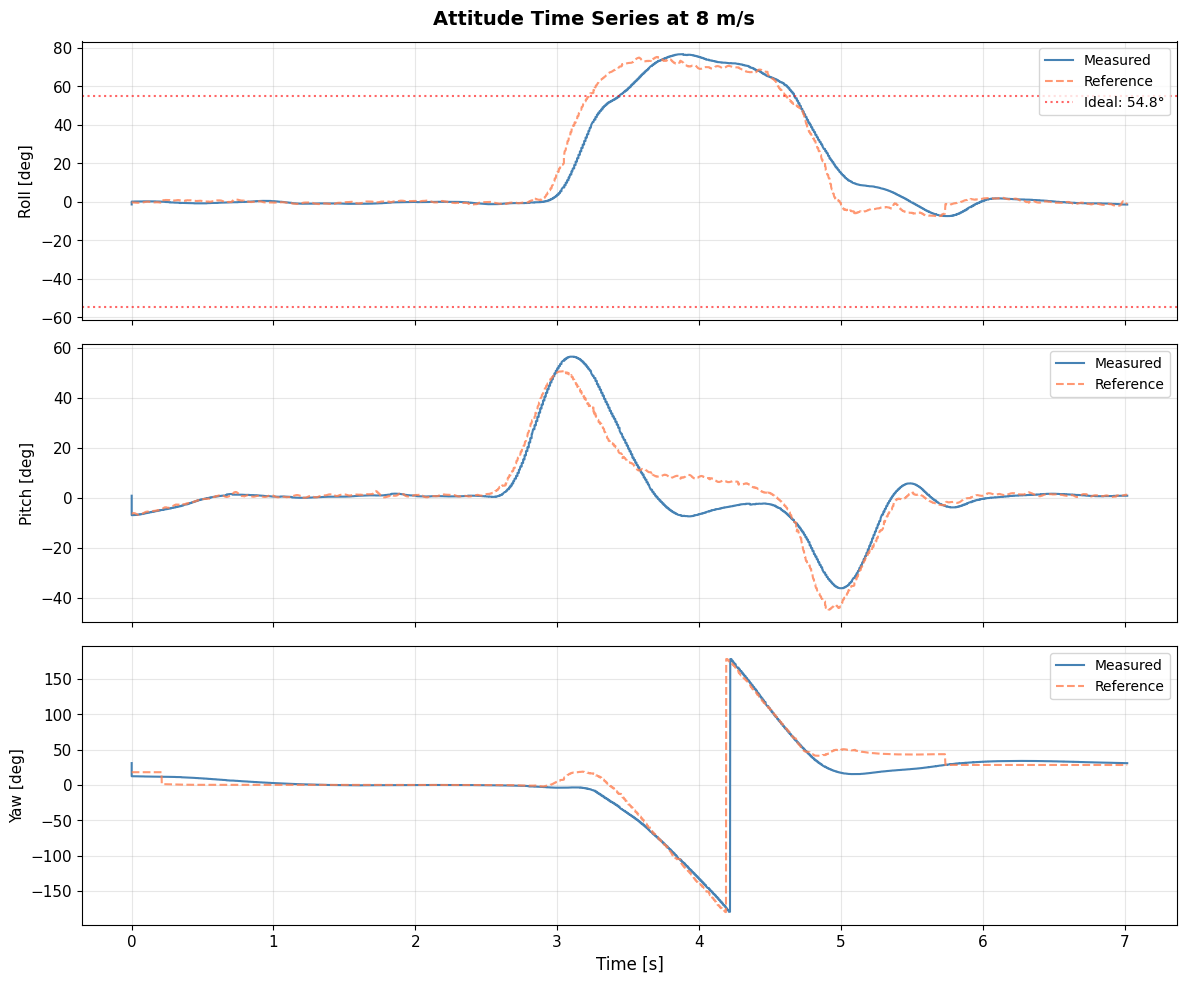

Attitude time series plot for 8 m/s generated


In [53]:
# Plot 4: Attitude time series at 8 m/s
speed_to_plot = 8

# Get time and angle data
time_roll = data[speed_to_plot]['roll_measured']['time'].values
time_pitch = data[speed_to_plot]['pitch_measured']['time'].values
time_yaw = data[speed_to_plot]['yaw_measured']['time'].values

roll_meas = data[speed_to_plot]['roll_measured']['value'].values
roll_ref = data[speed_to_plot]['roll_reference']['value'].values
pitch_meas = data[speed_to_plot]['pitch_measured']['value'].values
pitch_ref = data[speed_to_plot]['pitch_reference']['value'].values
yaw_meas = data[speed_to_plot]['yaw_measured']['value'].values
yaw_ref = data[speed_to_plot]['yaw_reference']['value'].values

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Roll
axes[0].plot(time_roll, roll_meas, color='steelblue', linewidth=1.5, label='Measured')
axes[0].plot(time_roll, roll_ref, color='coral', linewidth=1.5, linestyle='--', label='Reference', alpha=0.8)
ideal = circle_params[speed_to_plot]['ideal_bank_angle_deg']
axes[0].axhline(y=ideal, color='red', linestyle=':', linewidth=1.5, label=f'Ideal: {ideal:.1f}°', alpha=0.6)
axes[0].axhline(y=-ideal, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
axes[0].set_ylabel('Roll [deg]', fontsize=11)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Pitch
axes[1].plot(time_pitch, pitch_meas, color='steelblue', linewidth=1.5, label='Measured')
axes[1].plot(time_pitch, pitch_ref, color='coral', linewidth=1.5, linestyle='--', label='Reference', alpha=0.8)
axes[1].set_ylabel('Pitch [deg]', fontsize=11)
axes[1].legend(fontsize=10, loc='upper right')
axes[1].grid(True, alpha=0.3)

# Yaw
axes[2].plot(time_yaw, yaw_meas, color='steelblue', linewidth=1.5, label='Measured')
axes[2].plot(time_yaw, yaw_ref, color='coral', linewidth=1.5, linestyle='--', label='Reference', alpha=0.8)
axes[2].set_ylabel('Yaw [deg]', fontsize=11)
axes[2].set_xlabel('Time [s]', fontsize=12)
axes[2].legend(fontsize=10, loc='upper right')
axes[2].grid(True, alpha=0.3)

fig.suptitle(f'Attitude Time Series at {speed_to_plot} m/s', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Attitude time series plot for {speed_to_plot} m/s generated")

## Additional Analysis Plots

### Load Additional Data

## Export Data to CSV Files for LaTeX

Now we'll export the processed data to CSV files that can be used with pgfplots in LaTeX.

In [54]:
# Create output directory
output_dir = Path('../data')
output_dir.mkdir(exist_ok=True)

# Export 1: Trajectories for each speed
for speed in speeds:
    if 'x_measured' not in data[speed] or 'y_measured' not in data[speed]:
        print(f"Warning: Skipping export for speed {speed} m/s - missing position data")
        continue
        
    # Measured trajectory
    export_df = pd.DataFrame({
        'x': data[speed]['x_measured']['value'].values,
        'y': data[speed]['y_measured']['value'].values
    })
    
    filename = output_dir / f'circle_trajectory_{int(speed*10)}mps.csv'
    export_df.to_csv(filename, index=False)
    print(f"Exported: {filename}")

# Export 2: Reference circle (using first speed with data as template)
ref_speed = None
for speed in speeds:
    if 'x_reference' in data[speed] and 'y_reference' in data[speed]:
        ref_speed = speed
        break

if ref_speed is not None:
    ref_circle = pd.DataFrame({
        'x': data[ref_speed]['x_reference']['value'].values,
        'y': data[ref_speed]['y_reference']['value'].values
    })
    filename = output_dir / 'circle_reference.csv'
    ref_circle.to_csv(filename, index=False)
    print(f"Exported: {filename}")

print("\nTrajectory data exported successfully!")

Exported: ../data/circle_trajectory_30mps.csv
Exported: ../data/circle_trajectory_50mps.csv
Exported: ../data/circle_trajectory_65mps.csv
Exported: ../data/circle_trajectory_80mps.csv
Exported: ../data/circle_reference.csv

Trajectory data exported successfully!


In [55]:
# Export 3: Tracking error vs speed
tracking_summary = pd.DataFrame({
    'speed': list(tracking_metrics.keys()),
    'rms_error_3d': [tracking_metrics[s]['rms_error'] for s in tracking_metrics.keys()],
    'rms_error_xy': [tracking_metrics[s]['rms_error_xy'] for s in tracking_metrics.keys()],
    'max_error_xy': [tracking_metrics[s]['max_error'] for s in tracking_metrics.keys()],
    'max_error_3d': [tracking_metrics[s]['max_error_3d'] for s in tracking_metrics.keys()],
    'mean_error': [tracking_metrics[s]['mean_error'] for s in tracking_metrics.keys()]
})

filename = output_dir / 'circle_tracking_errors.csv'
tracking_summary.to_csv(filename, index=False)
print(f"Exported: {filename}")

# Export 4: Bank angle vs speed
bank_summary = pd.DataFrame({
    'speed': list(bank_angles.keys()),
    'mean_bank': [bank_angles[s]['mean_abs_bank'] for s in bank_angles.keys()],
    'max_bank': [bank_angles[s]['max_abs_bank'] for s in bank_angles.keys()],
    'ideal_bank': [bank_angles[s]['ideal_bank'] for s in bank_angles.keys()]
})

filename = output_dir / 'circle_bank_angles.csv'
bank_summary.to_csv(filename, index=False)
print(f"Exported: {filename}")

print("\nMetrics data exported successfully!")

Exported: ../data/circle_tracking_errors.csv
Exported: ../data/circle_bank_angles.csv

Metrics data exported successfully!


In [56]:
# Export 5: Attitude time series at 8 m/s
speed_to_export = 8

attitude_df = pd.DataFrame({
    'time': data[speed_to_export]['roll_measured']['time'].values,
    'roll_measured': data[speed_to_export]['roll_measured']['value'].values,
    'roll_reference': data[speed_to_export]['roll_reference']['value'].values,
    'pitch_measured': data[speed_to_export]['pitch_measured']['value'].values,
    'pitch_reference': data[speed_to_export]['pitch_reference']['value'].values,
    'yaw_measured': data[speed_to_export]['yaw_measured']['value'].values,
    'yaw_reference': data[speed_to_export]['yaw_reference']['value'].values
})

filename = output_dir / f'circle_attitude_{speed_to_export}mps.csv'
attitude_df.to_csv(filename, index=False)
print(f"Exported: {filename}")

print("\nAttitude time series data exported successfully!")

Exported: ../data/circle_attitude_8mps.csv

Attitude time series data exported successfully!


In [57]:
# Export 6: Motor speed vs flight speed
if len(motor_speeds) > 0:
    motor_summary = pd.DataFrame({
        'speed': list(motor_speeds.keys()),
        'mean_rpm': [motor_speeds[s]['mean_rpm'] for s in motor_speeds.keys()],
        'std_rpm': [motor_speeds[s]['std_rpm'] for s in motor_speeds.keys()],
        'max_rpm': [motor_speeds[s]['max_rpm'] for s in motor_speeds.keys()],
        'min_rpm': [motor_speeds[s]['min_rpm'] for s in motor_speeds.keys()]
    })
    
    filename = output_dir / 'circle_motor_speeds.csv'
    motor_summary.to_csv(filename, index=False)
    print(f"Exported: {filename}")

print("\nMotor speed data exported successfully!")

Exported: ../data/circle_motor_speeds.csv

Motor speed data exported successfully!


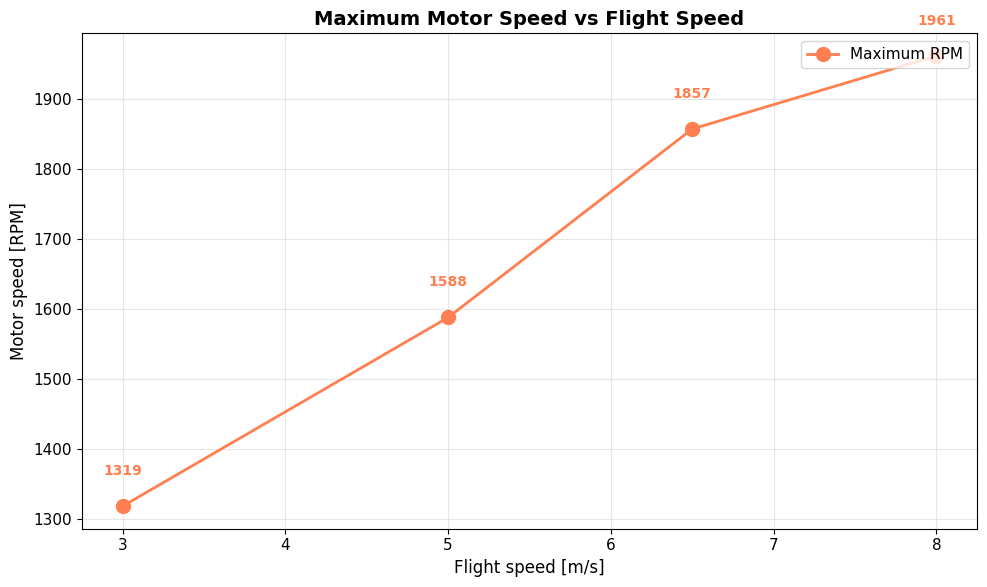

Motor speed vs flight speed plot generated

Maximum motor speed summary:
Speed [m/s]     Max RPM        
----------------------------------------
3.0             1318.7         
5.0             1587.9         
6.5             1856.9         
8.0             1961.2         


In [58]:
# Plot 7: Maximum Motor Speed vs Flight Speed
fig, ax = plt.subplots(figsize=(10, 6))

speeds_list = list(motor_speeds.keys())
max_rpms = [motor_speeds[s]['max_rpm'] for s in speeds_list]

# Plot only max motor speeds
ax.plot(speeds_list, max_rpms, 'o-', linewidth=2, markersize=10, 
        color='coral', label='Maximum RPM')

ax.set_xlabel('Flight speed [m/s]', fontsize=12)
ax.set_ylabel('Motor speed [RPM]', fontsize=12)
ax.set_title('Maximum Motor Speed vs Flight Speed', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

# Add value labels on max points
for speed, rpm in zip(speeds_list, max_rpms):
    ax.text(speed, rpm + 40, f'{rpm:.0f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='coral')

plt.tight_layout()
plt.show()

print("Motor speed vs flight speed plot generated")
print("\nMaximum motor speed summary:")
print("="*40)
print(f"{'Speed [m/s]':<15} {'Max RPM':<15}")
print("-"*40)
for speed in speeds_list:
    print(f"{speed:<15.1f} {motor_speeds[speed]['max_rpm']:<15.1f}")
print("="*40)

In [59]:
# Export 8: Motor speed data for plotting in LaTeX
if len(motor_speeds) > 0:
    # Create a simple dataframe with just speed and max RPM for the plot
    motor_plot_data = pd.DataFrame({
        'speed': list(motor_speeds.keys()),
        'max_rpm': [motor_speeds[s]['max_rpm'] for s in motor_speeds.keys()]
    })
    
    filename = output_dir / 'circle_motor_speeds_plot.csv'
    motor_plot_data.to_csv(filename, index=False)
    print(f"Exported: {filename}")
    print(f"  Columns: {list(motor_plot_data.columns)}")
    print(f"  Data points: {len(motor_plot_data)}")
    
    print("\nMotor speed plot data exported successfully!")
else:
    print("Warning: No motor speed data available to export")

Exported: ../data/circle_motor_speeds_plot.csv
  Columns: ['speed', 'max_rpm']
  Data points: 4

Motor speed plot data exported successfully!


In [60]:
# Verify exported files
print("Verifying exported CSV files:\n")

csv_files = sorted(output_dir.glob('circle_*.csv'))
csv_files.append(output_dir / 'circle_reference.csv')

for file in csv_files:
    if file.exists():
        df = pd.read_csv(file)
        print(f"✓ {file.name}")
        print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
        print(f"  Columns: {list(df.columns)}")
        print()

print(f"\nAll {len(csv_files)} CSV files exported successfully!")
print(f"Output directory: {output_dir.absolute()}")

Verifying exported CSV files:

✓ circle_attitude_8mps.csv
  Shape: 2811 rows × 7 columns
  Columns: ['time', 'roll_measured', 'roll_reference', 'pitch_measured', 'pitch_reference', 'yaw_measured', 'yaw_reference']

✓ circle_bank_angles.csv
  Shape: 4 rows × 4 columns
  Columns: ['speed', 'mean_bank', 'max_bank', 'ideal_bank']

✓ circle_max_bank_angles.csv
  Shape: 4 rows × 4 columns
  Columns: ['speed', 'max_roll', 'min_roll', 'max_abs_roll']

✓ circle_motor_speeds.csv
  Shape: 4 rows × 5 columns
  Columns: ['speed', 'mean_rpm', 'std_rpm', 'max_rpm', 'min_rpm']

✓ circle_motor_speeds_plot.csv
  Shape: 4 rows × 2 columns
  Columns: ['speed', 'max_rpm']

✓ circle_position_error_8mps.csv
  Shape: 2811 rows × 5 columns
  Columns: ['time', 'error_x', 'error_y', 'error_z', 'error_horizontal']

✓ circle_reference.csv
  Shape: 3661 rows × 2 columns
  Columns: ['x', 'y']

✓ circle_tracking_errors.csv
  Shape: 4 rows × 6 columns
  Columns: ['speed', 'rms_error_3d', 'rms_error_xy', 'max_error_xy'

## Summary

This notebook has processed the circular trajectory agility test data and generated:

**Data Format:**
- Each CSV file contains multiple topics (time series) identified by the `topic` column
- Position data: `/mocap/xwing/pose.pose.position.{x,y,z}` (measured) and `/xwing/agiros_pilot/telemetry.reference.pose.position.{x,y,z}` (reference)
- Orientation data: `/studio/euler_deg.{meas,ref}_{roll,pitch,yaw}_deg`
- Error data: `/studio/euler_deg.err_{roll,pitch,yaw}_deg`

**Visualizations:**
1. 2D trajectory comparison for all speeds (measured + reference)
2. Tracking error vs speed (RMS and max)
3. Bank angle vs speed (measured vs ideal)
4. Attitude time series at 8 m/s (roll, pitch, yaw with measured and reference)

**Exported CSV files for LaTeX:**
- `circle_trajectory_30mps.csv` - 3 m/s measured trajectory (x, y)
- `circle_trajectory_50mps.csv` - 5 m/s measured trajectory (x, y)
- `circle_trajectory_65mps.csv` - 6.5 m/s measured trajectory (x, y)
- `circle_trajectory_80mps.csv` - 8 m/s measured trajectory (x, y)
- `circle_reference.csv` - Reference circle trajectory (x, y)
- `circle_tracking_errors.csv` - Tracking metrics (speed, rms_error, max_error, mean_error)
- `circle_bank_angles.csv` - Bank angle data (speed, mean_bank, max_bank, ideal_bank)
- `circle_attitude_8mps.csv` - Attitude time series at 8 m/s (time, roll_measured, roll_reference, pitch_measured, pitch_reference, yaw_measured, yaw_reference)

These CSV files can now be imported in LaTeX using pgfplots for publication-quality figures in the thesis.

In [61]:
# Load position error data for time series analysis
position_errors = {}

for speed in speeds:
    folder = base_path / speed_folders[speed]
    
    try:
        err_x = load_topic_data(folder / 'pos_error.csv', '/studio/pos_error_xyz.err_x')
        err_y = load_topic_data(folder / 'pos_error.csv', '/studio/pos_error_xyz.err_y')
        err_z = load_topic_data(folder / 'pos_error.csv', '/studio/pos_error_xyz.err_z')
        
        if len(err_x) > 0:
            # Calculate horizontal error magnitude
            horizontal_error = np.sqrt(err_x['value'].values**2 + err_y['value'].values**2)
            
            position_errors[speed] = {
                'time': err_x['time'].values,
                'err_x': err_x['value'].values,
                'err_y': err_y['value'].values,
                'err_z': err_z['value'].values,
                'horizontal_error': horizontal_error
            }
            
            print(f"Speed {speed} m/s: Position error time series loaded ({len(err_x)} points)")
    except Exception as e:
        print(f"Warning: Could not load position error for {speed} m/s: {e}")

print("\nPosition error data loaded!")

Speed 3 m/s: Position error time series loaded (4880 points)
Speed 5 m/s: Position error time series loaded (2404 points)
Speed 6.5 m/s: Position error time series loaded (2417 points)
Speed 8 m/s: Position error time series loaded (2811 points)

Position error data loaded!


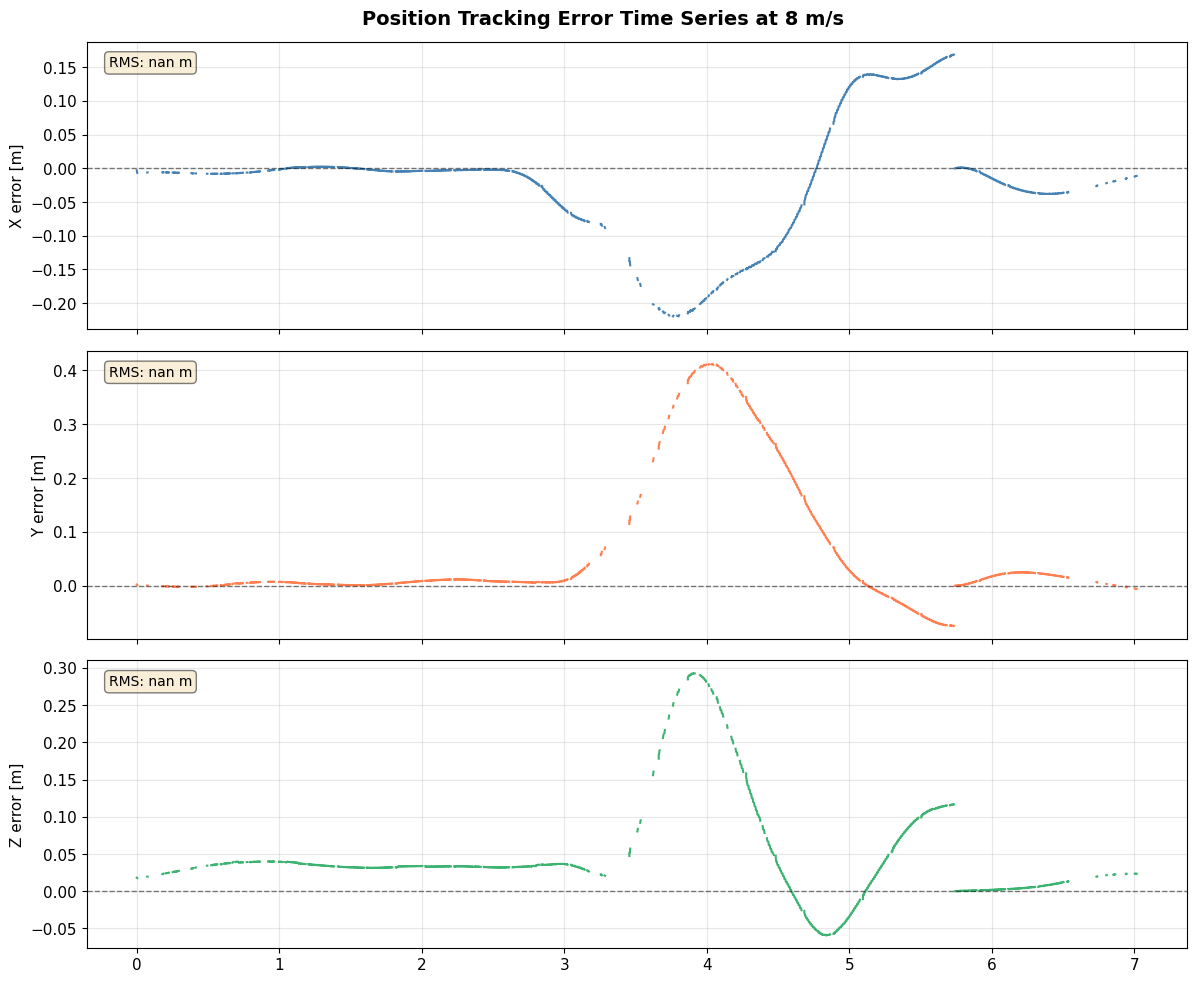

Tracking error time series plot for 8 m/s generated


In [62]:
# Plot 6: Tracking Error Time Series at 8 m/s
speed_to_plot = 8

if speed_to_plot in position_errors:
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    time = position_errors[speed_to_plot]['time']
    err_x = position_errors[speed_to_plot]['err_x']
    err_y = position_errors[speed_to_plot]['err_y']
    err_z = position_errors[speed_to_plot]['err_z']
    horizontal_error = position_errors[speed_to_plot]['horizontal_error']
    
    # X error
    axes[0].plot(time, err_x, color='steelblue', linewidth=1.5)
    axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylabel('X error [m]', fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].text(0.02, 0.95, f'RMS: {np.sqrt(np.mean(err_x**2)):.3f} m', 
                 transform=axes[0].transAxes, fontsize=10, 
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Y error
    axes[1].plot(time, err_y, color='coral', linewidth=1.5)
    axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylabel('Y error [m]', fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].text(0.02, 0.95, f'RMS: {np.sqrt(np.mean(err_y**2)):.3f} m', 
                 transform=axes[1].transAxes, fontsize=10, 
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Z error
    axes[2].plot(time, err_z, color='mediumseagreen', linewidth=1.5)
    axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[2].set_ylabel('Z error [m]', fontsize=11)
    axes[2].grid(True, alpha=0.3)
    axes[2].text(0.02, 0.95, f'RMS: {np.sqrt(np.mean(err_z**2)):.3f} m', 
                 transform=axes[2].transAxes, fontsize=10, 
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    
    fig.suptitle(f'Position Tracking Error Time Series at {speed_to_plot} m/s', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Tracking error time series plot for {speed_to_plot} m/s generated")
else:
    print(f"Warning: No position error data available for {speed_to_plot} m/s")

In [63]:
# Export 7: Position error time series at 8 m/s
speed_to_export = 8

if speed_to_export in position_errors:
    error_df = pd.DataFrame({
        'time': position_errors[speed_to_export]['time'],
        'error_x': position_errors[speed_to_export]['err_x'],
        'error_y': position_errors[speed_to_export]['err_y'],
        'error_z': position_errors[speed_to_export]['err_z'],
        'error_horizontal': position_errors[speed_to_export]['horizontal_error']
    })
    
    filename = output_dir / f'circle_position_error_{speed_to_export}mps.csv'
    error_df.to_csv(filename, index=False)
    print(f"Exported: {filename}")
    
    print("\nPosition error time series data exported successfully!")
else:
    print(f"Warning: No position error data available for {speed_to_export} m/s")

Exported: ../data/circle_position_error_8mps.csv

Position error time series data exported successfully!


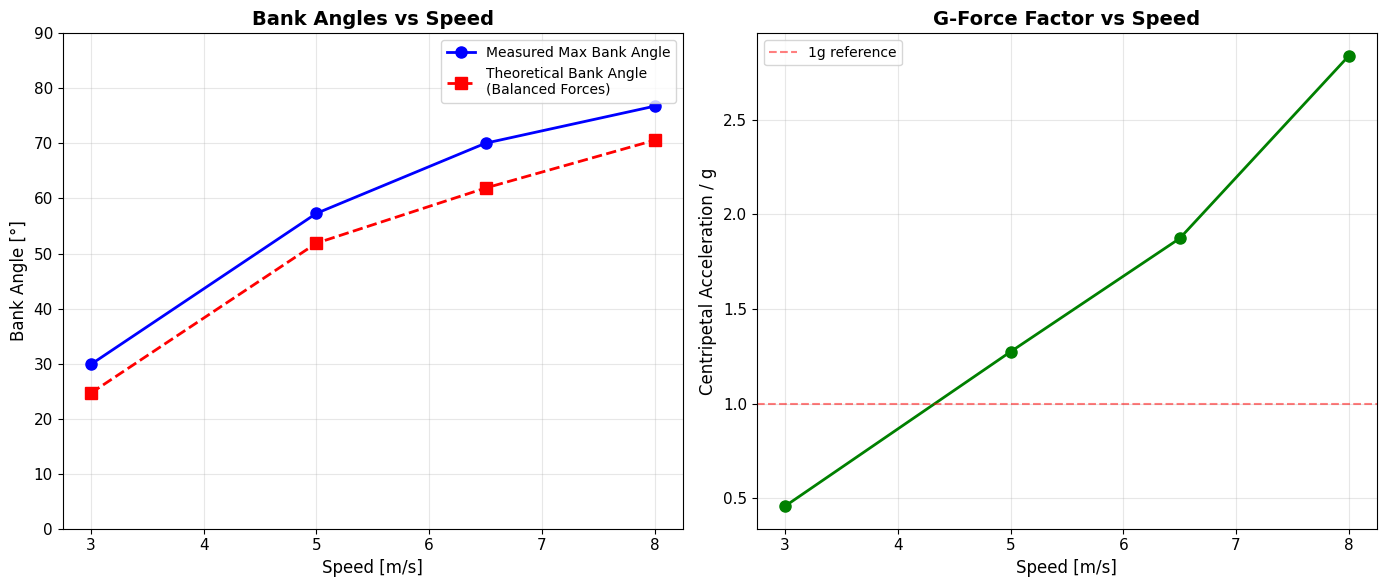


BANK ANGLE ANALYSIS
Speed      Measured     Theoretical  Difference   a_c/g     
[m/s]      Max [°]      Ideal [°]    [°]          [-]       
--------------------------------------------------------------------------------
3.0        29.85        24.64        5.21         0.46      
5.0        57.29        51.88        5.41         1.27      
6.5        70.04        61.90        8.14         1.87      
8.0        76.77        70.58        6.19         2.84      

✓ Exported: ../data/circle_bank_angle_comparison.csv


In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Data from the table - using actual measured maximum roll angles
speeds = np.array([3, 5, 6.5, 8])  # m/s
centripetal_accel = np.array([4.5, 12.5, 18.37, 27.83])  # m/s^2
measured_bank_angles = np.array([29.85, 57.29, 70.04, 76.77])  # degrees - ACTUAL MAX from data
rms_error = np.array([0.064, 0.109, 0.137, 0.162])  # m
max_error = np.array([0.088, 0.310, 0.386, 0.538])  # m
max_motor_speed = np.array([1319, 1588, 1857, 1961])  # rpm

# Calculate theoretical bank angle for a quad in steady circular flight
# tan(bank_angle) = centripetal_acceleration / g
# bank_angle = arctan(a_c / g)
g = 9.81  # m/s^2
theoretical_bank_angles = np.degrees(np.arctan(centripetal_accel / g))

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Bank angles comparison
ax1.plot(speeds, measured_bank_angles, 'o-', label='Measured Max Bank Angle', 
         linewidth=2, markersize=8, color='blue')
ax1.plot(speeds, theoretical_bank_angles, 's--', label='Theoretical Bank Angle\n(Balanced Forces)', 
         linewidth=2, markersize=8, color='red')
ax1.set_xlabel('Speed [m/s]', fontsize=12)
ax1.set_ylabel('Bank Angle [°]', fontsize=12)
ax1.set_title('Bank Angles vs Speed', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_ylim([0, 90])

# Plot 2: Centripetal acceleration / g ratio
ax2.plot(speeds, centripetal_accel / g, 'o-', linewidth=2, markersize=8, color='green')
ax2.set_xlabel('Speed [m/s]', fontsize=12)
ax2.set_ylabel('Centripetal Acceleration / g', fontsize=12)
ax2.set_title('G-Force Factor vs Speed', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1, color='red', linestyle='--', label='1g reference', alpha=0.5)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../data/bank_angles_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison table
print("\n" + "="*80)
print("BANK ANGLE ANALYSIS")
print("="*80)
print(f"{'Speed':<10} {'Measured':<12} {'Theoretical':<12} {'Difference':<12} {'a_c/g':<10}")
print(f"{'[m/s]':<10} {'Max [°]':<12} {'Ideal [°]':<12} {'[°]':<12} {'[-]':<10}")
print("-"*80)
for i in range(len(speeds)):
    diff = measured_bank_angles[i] - theoretical_bank_angles[i]
    g_factor = centripetal_accel[i] / g
    print(f"{speeds[i]:<10.1f} {measured_bank_angles[i]:<12.2f} {theoretical_bank_angles[i]:<12.2f} "
          f"{diff:<12.2f} {g_factor:<10.2f}")
print("="*80)

# Export comparison data
comparison_df = pd.DataFrame({
    'speed': speeds,
    'measured_max_bank': measured_bank_angles,
    'theoretical_bank': theoretical_bank_angles,
    'difference': measured_bank_angles - theoretical_bank_angles,
    'g_factor': centripetal_accel / g
})

filename = output_dir / 'circle_bank_angle_comparison.csv'
comparison_df.to_csv(filename, index=False)
print(f"\n✓ Exported: {filename}")

In [65]:
# Extract maximum bank angles (roll) for all speeds
max_bank_angles_summary = {}

print("Maximum Bank Angles (Roll) for Each Speed:")
print("=" * 60)
print(f"{'Speed [m/s]':<15} {'Max Roll [°]':<20} {'Min Roll [°]':<20}")
print("-" * 60)

for speed in speeds:
    folder = base_path / speed_folders[speed]
    
    try:
        # Load roll data
        roll_data = load_topic_data(folder / 'roll.csv', topics['roll_measured'])
        
        if len(roll_data) > 0:
            roll_values = roll_data['value'].values
            
            max_roll = np.max(roll_values)
            min_roll = np.min(roll_values)
            max_abs_roll = np.max(np.abs(roll_values))
            
            max_bank_angles_summary[speed] = {
                'max_roll': max_roll,
                'min_roll': min_roll,
                'max_abs_roll': max_abs_roll
            }
            
            print(f"{speed:<15.1f} {max_roll:<20.2f} {min_roll:<20.2f}")
            
    except Exception as e:
        print(f"Error loading data for {speed} m/s: {e}")

print("=" * 60)
print("\nMaximum Absolute Bank Angles (Most Extreme):")
print("-" * 60)
for speed in sorted(max_bank_angles_summary.keys()):
    max_abs = max_bank_angles_summary[speed]['max_abs_roll']
    print(f"Speed {speed} m/s: {max_abs:.2f}°")
print("=" * 60)

# Export to CSV for LaTeX
if len(max_bank_angles_summary) > 0:
    max_bank_df = pd.DataFrame({
        'speed': list(max_bank_angles_summary.keys()),
        'max_roll': [max_bank_angles_summary[s]['max_roll'] for s in max_bank_angles_summary.keys()],
        'min_roll': [max_bank_angles_summary[s]['min_roll'] for s in max_bank_angles_summary.keys()],
        'max_abs_roll': [max_bank_angles_summary[s]['max_abs_roll'] for s in max_bank_angles_summary.keys()]
    })
    
    filename = output_dir / 'circle_max_bank_angles.csv'
    max_bank_df.to_csv(filename, index=False)
    print(f"\n✓ Exported: {filename}")

Maximum Bank Angles (Roll) for Each Speed:
Speed [m/s]     Max Roll [°]         Min Roll [°]        
------------------------------------------------------------
3.0             29.85                -1.34               
5.0             57.29                -0.86               
6.5             70.04                -3.58               
8.0             76.77                -7.44               

Maximum Absolute Bank Angles (Most Extreme):
------------------------------------------------------------
Speed 3.0 m/s: 29.85°
Speed 5.0 m/s: 57.29°
Speed 6.5 m/s: 70.04°
Speed 8.0 m/s: 76.77°

✓ Exported: ../data/circle_max_bank_angles.csv
